## RL Book Graphics 2
- Made descent progress on the supporting code, bringing that over here for nice uniformity, and doing the more complex renders we need for the book. 

In [10]:
import gymnasium as gym
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from tqdm import tqdm
import json
from pathlib import Path as FilePath
from matplotlib.path import Path
from matplotlib.markers import MarkerStyle
from matplotlib.patches import FancyBboxPatch, Circle

CHILL_BROWN="#948979"
FRESH_TAN="#f4ebd9"
ORANGE='#eb8423'
LT_BLUE='#5badb6'
GREEN='#419c52'
RED='#d73b2f'

DATA = FilePath("/Users/stephen/ai_book_vol_2/chapters/02-reinforcement-learning/data")  # Chapter data lives next to the notebook

import matplotlib.colors as mcolors
cmap = mcolors.LinearSegmentedColormap.from_list("blue_orange", [LT_BLUE, ORANGE], N=256)

In [19]:
HACKIN_DIR = '/Volumes/hot_1/Stephencwelch Dropbox/welch_labs/rl_1/hackin'
# HACKIN_DIR = '/Users/stephen/Library/CloudStorage/Dropbox-Stephencwelch/welch_labs/rl_1/hackin'

SAVE_DIR = '/Volumes/hot_1/Stephencwelch Dropbox/welch_labs/ai_book_vol_2/2_reinforcement_learning/graphics'
# SAVE_DIR = '/Users/stephen/Library/CloudStorage/Dropbox-Stephencwelch/welch_labs/ai_book_vol_2/2_reinforcement_learning/graphics/'


In [ ]:
def style_ax(ax, color=CHILL_BROWN):
    ax.spines[:].set_color(color)
    ax.tick_params(colors=color, which='both')
    ax.xaxis.label.set_color(color)
    ax.yaxis.label.set_color(color)
    ax.title.set_color(color)

In [22]:
def arrow_path(direction=1, shaft_w=0.28, head_w=0.9, head_len=0.9, total_len=2.0):
    hl = head_len; sw = shaft_w/2; hw = head_w/2; L = total_len/2
    verts = np.array([
        (-L,  sw), (L-hl,  sw), (L-hl,  hw), (L, 0),
        (L-hl, -hw), (L-hl, -sw), (-L, -sw), (-L, sw),
    ]) * direction   # direction=-1 mirrors -> left arrow
    codes = [Path.MOVETO] + [Path.LINETO]*6 + [Path.CLOSEPOLY]
    return Path(verts, codes)

RIGHT_ARROW = MarkerStyle(arrow_path(+1))
LEFT_ARROW  = MarkerStyle(arrow_path(-1))

CART_W, CART_H, POLE_LEN, WHEEL_R = 0.5, 0.26, 1.0, 0.09
X_LIM = (-2.4, 2.4)

def draw_cartpole(ax, cart_x, pole_theta, action=None, y0=0.0,
                  setup_axes=True, track=True, arrow_size=420, arrow_dy=-0.32, stroke_color='k', fill_color='w'):
    """Draw one cart-pole state with its track baseline at y=y0."""
    if setup_axes:
        ax.set_xlim(*X_LIM); ax.set_ylim(y0-0.55, y0+1.75)
        ax.set_aspect('equal'); ax.axis('off')
    if track:
        ax.plot(X_LIM, [y0, y0], color=CHILL_BROWN, lw=1.5, zorder=1)
    cart_y = y0 + WHEEL_R*2
    for dx in (-CART_W*0.3, CART_W*0.3):
        ax.add_patch(Circle((cart_x+dx, y0+WHEEL_R), WHEEL_R, color=stroke_color, zorder=3))
    ax.add_patch(FancyBboxPatch((cart_x-CART_W/2, cart_y), CART_W, CART_H,
                 boxstyle="round,pad=0.02,rounding_size=0.05",
                 fc=fill_color, ec=stroke_color, lw=2.0, zorder=4))
    px, py = cart_x, cart_y + CART_H
    ax.plot([px, px + POLE_LEN*np.sin(pole_theta)],
            [py, py + POLE_LEN*np.cos(pole_theta)],
            color=stroke_color, lw=3, solid_capstyle='round', zorder=5)
    ax.add_patch(Circle((px, py), 0.07, color=stroke_color, zorder=6))
    if action is not None:   # needs RIGHT_ARROW / LEFT_ARROW defined
        ax.scatter([cart_x], [y0+arrow_dy],
                   marker=(RIGHT_ARROW if action==1 else LEFT_ARROW), s=arrow_size,
                   color=(YELLOW if action==1 else BLUE), linewidths=0, zorder=5)


def episode_frame_indices(n_steps, n_plots):
    """Evenly spaced step indices, always including the first and last step."""
    return np.unique(np.round(np.linspace(0, n_steps-1, n_plots)).astype(int))


def draw_episode(cart_xs, pole_thetas, n_plots, actions=None, spacing=1.6,
                 ax=None, fig_width=3.0, show_actions=False, label_steps=False,
                 pad_top=1.75, pad_bottom=0.55, top_down=True, **cartpole_kwargs):
    """
    Stack n_plots cart-pole states vertically in a single axis.

    spacing   : vertical distance between track baselines, in data units
                (the cart+pole is ~1.4 tall, so spacing < 1.4 will overlap).
    top_down  : first step at the top (True) or bottom (False).
    Returns fig, ax, idx (the step indices drawn), ys (baseline y of each frame).
    """
    cart_xs, pole_thetas = np.asarray(cart_xs), np.asarray(pole_thetas)
    idx = episode_frame_indices(len(cart_xs), n_plots)
    ys = -spacing*np.arange(len(idx)) if top_down else spacing*np.arange(len(idx))

    if ax is None:
        x_range = X_LIM[1]-X_LIM[0]
        y_range = spacing*(len(idx)-1) + pad_top + pad_bottom
        fig = plt.figure(figsize=(fig_width, fig_width*y_range/x_range))
        ax = fig.add_subplot(111)
    else:
        fig = ax.figure

    for t, y0 in zip(idx, ys):
        a = actions[t] if (show_actions and actions is not None) else None
        draw_cartpole(ax, cart_xs[t], pole_thetas[t], action=a, y0=y0,
                      setup_axes=False, **cartpole_kwargs)
        if label_steps:
            ax.text(X_LIM[0]-0.15, y0+0.1, f't={t}', ha='right', va='bottom',
                    color=CHILL_BROWN, fontsize=8)

    ax.set_xlim(*X_LIM)
    ax.set_ylim(ys.min()-pad_bottom, ys.max()+pad_top)
    ax.set_aspect('equal'); ax.axis('off')
    return fig, ax, idx, ys

In [12]:
with open(DATA / "sw_cartpole_game.json") as f: 
    data = json.load(f)

VEL_SCALE = 10   # divide velocities by 10 -> feature scales comparable, ~isotropic parameter space
obs = torch.tensor(data["episodes"][0]["observations"]) 
X = obs[:, 2:4] * 180/np.pi # Here we'll just use pole angle and pole angular velocity, and use degrees
X[:,1] = X[:,1] / VEL_SCALE # Scale pole angular velocity
y = torch.tensor(data['episodes'][0]['actions'])

In [13]:
X.shape, y.shape #This game is 66 steps long

(torch.Size([66, 2]), torch.Size([66]))

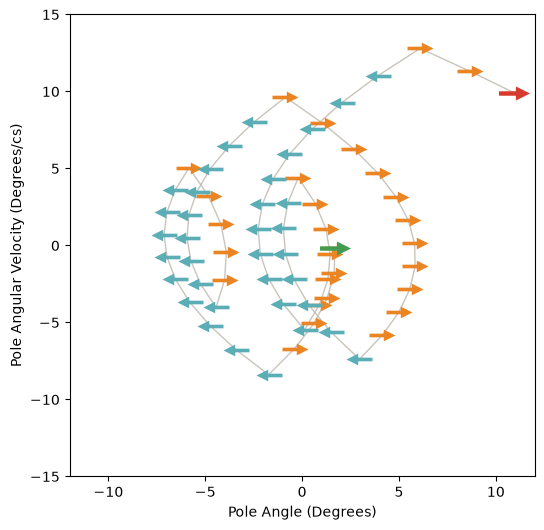

In [21]:
fig=plt.figure(0, (6,6))
ax=fig.add_subplot(111)

m = (y == 1)
plt.plot(X[:,0], X[:,1], color=CHILL_BROWN, lw=1, alpha=0.5, zorder=-10)
ax.scatter(X[m, 0],  X[m, 1],  marker=RIGHT_ARROW, s=350, color=ORANGE, alpha=1.0, linewidths=0)
ax.scatter(X[~m, 0], X[~m, 1], marker=LEFT_ARROW,  s=350, color=LT_BLUE,   alpha=1.0, linewidths=0)
ax.scatter(X[0, 0],  X[0, 1],  marker= RIGHT_ARROW if y[0]==1 else LEFT_ARROW, s=500, color=GREEN, alpha=1.0, linewidths=0) #First step green
ax.scatter(X[-1, 0],  X[-1, 1],  marker= RIGHT_ARROW if y[-1]==1 else LEFT_ARROW, s=500, color=RED, alpha=1.0, linewidths=0) #Last step red
plt.xlabel('Pole Angle (Degrees)'); plt.ylabel('Pole Angular Velocity (Degrees/cs)')
plt.xlim([-12, 12]); plt.ylim([-15, 15])

plt.savefig(SAVE_DIR+'/state_space_1b.svg')

- Ok noodling in illustrator here, would like to render out separate `draw_cartpole` svgs for each each step, then I'll use a few for callouts from the state space diagram. 

In [23]:
ep = data["episodes"][0]
obs_np = np.asarray(ep["observations"])   # columns: cart_x, cart_v, pole_theta, pole_omega
acts   = np.asarray(ep["actions"])

FRAME_DIR = FilePath(SAVE_DIR) / "cartpole_frames"
FRAME_DIR.mkdir(parents=True, exist_ok=True)

SHOW_ACTIONS = False   # set True to draw the left/right arrow under the cart

for t in tqdm(range(len(obs_np))):
    fig = plt.figure(figsize=(3.0, 1.45))   # matches X_LIM (4.8 wide) x (0.55+1.75 tall) at equal aspect
    ax = fig.add_subplot(111)
    draw_cartpole(ax, obs_np[t, 0], obs_np[t, 2],
                  action=acts[t] if SHOW_ACTIONS else None)
    fig.savefig(FRAME_DIR / f"step_{t:02d}.svg", bbox_inches="tight", pad_inches=0.02)
    plt.close(fig)

print(f"Saved {len(obs_np)} frames to {FRAME_DIR}")

100%|███████████████████████████████████████████████████████| 66/66 [00:00<00:00, 153.60it/s]

Saved 66 frames to /Volumes/hot_1/Stephencwelch Dropbox/welch_labs/ai_book_vol_2/2_reinforcement_learning/graphics/cartpole_frames


Ok ok ok ok ok ok ok ok now we need network overlay on top of state space. 

In [24]:
class Pi(nn.Module):
    """Two-parameter policy: logit = theta1 * pole_angle + theta2 * pole_ang_velocity."""
    def __init__(self):
        super().__init__()
        self.theta = nn.Parameter(torch.zeros(2))  # [theta1, theta2] -> uniform random policy at init

    def forward(self, x):
        logit = x @ self.theta.to(x.dtype)         # compute at the precision of the input; we'll need double precision later
        return torch.sigmoid(logit)

In [25]:
agent=Pi()

In [ ]:
# #We can pass in a test state (angle=1, angular vel=2) and get the agent's output before training
# with torch.no_grad():
#     yhat=agent(torch. tensor([1,2]))
# yhat

In [26]:
ANG_LIM = (-15, 15) #Limits for the network output visualization
VEL_LIM = (-15, 15)   

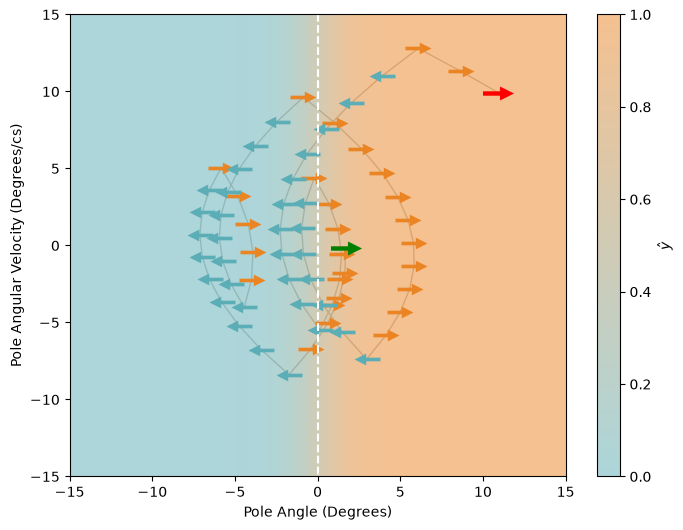

In [29]:
fig=plt.figure(0, (8,6))
ax=fig.add_subplot(111)

A, V = np.meshgrid(np.linspace(*ANG_LIM, 160), np.linspace(*VEL_LIM, 160))
with torch.no_grad():
    agent.theta[:] = torch.tensor([1.0, 0])
    grid = torch.tensor(np.stack([A.ravel(), V.ravel()], axis=1), dtype=torch.float32)  # (160*160, 2)
    yhat_grid = agent(grid).reshape(A.shape).numpy()                                     # back to (160, 160)

im = ax.imshow(yhat_grid, origin='lower', vmin=0, vmax=1, cmap=cmap,
               extent=[*ANG_LIM, *VEL_LIM], aspect='auto', alpha=0.5)
ax.contour(A, V, yhat_grid, levels=[0.5], colors='w', linestyles='--', linewidths=1.5)
plt.colorbar(im, label='$\hat{y}$')

m = (y == 1)
plt.plot(X[:,0], X[:,1], color=CHILL_BROWN, lw=1, alpha=0.5, zorder=-10)
ax.scatter(X[m, 0],  X[m, 1],  marker=RIGHT_ARROW, s=350, color=ORANGE, alpha=1.0, linewidths=0)
ax.scatter(X[~m, 0], X[~m, 1], marker=LEFT_ARROW,  s=350, color=LT_BLUE,   alpha=1.0, linewidths=0)
ax.scatter(X[0, 0],  X[0, 1],  marker= RIGHT_ARROW if y[0]==1 else LEFT_ARROW, s=500, color='g', alpha=1.0, linewidths=0) #First step green
ax.scatter(X[-1, 0],  X[-1, 1],  marker= RIGHT_ARROW if y[-1]==1 else LEFT_ARROW, s=500, color='r', alpha=1.0, linewidths=0) #Last step red
plt.xlabel('Pole Angle (Degrees)'); plt.ylabel('Pole Angular Velocity (Degrees/cs)')

plt.savefig(SAVE_DIR+'/state_space_with_overlay_1.svg')

Ok dope, now I want to make a nice table that shows how the L1 loss is computed. The table columns should be: step (starting at 1), x1, x2, y, yhat, |y-yhat|. I want a configurable number of space between entries, no commas, and zero padding so everything has two decimal places. I'll copy and past this into illustrator. 

In [32]:
SEP = 4          # minimum spaces between columns
N_STEPS = None   # e.g. 10 to only show the first 10 rows; None for all 66

with torch.no_grad():
    yhat = agent(X).squeeze()

n = len(X) if N_STEPS is None else N_STEPS
rows = [['step', 'x1', 'x2', 'y', 'yhat', '|y-yhat|']]
for t in range(n):
    rows.append([
        f'{t+1}',
        f'{X[t,0]:.2f}',
        f'{X[t,1]:.2f}',
        f'{int(y[t])}',
        f'{yhat[t]:.2f}',
        f'{abs(y[t]-yhat[t]):.2f}',
    ])

widths = [max(len(r[c]) for r in rows) for c in range(len(rows[0]))]
gap = ' ' * SEP
table = '\n'.join(gap.join(cell.rjust(w) for cell, w in zip(r, widths)) for r in rows)
print(table)
print(f'\nmean L1 loss = {abs(y[:n]-yhat[:n]).mean():.2f}')

step       x1       x2    y    yhat    |y-yhat|
   1     1.69    -0.16    1    0.84        0.16
   2     1.66    -1.78    1    0.84        0.16
   3     1.30    -3.41    1    0.79        0.21
   4     0.62    -5.04    1    0.65        0.35
   5    -0.39    -6.70    1    0.40        0.60
   6    -1.73    -8.39    0    0.15        0.15
   7    -3.41    -6.77    0    0.03        0.03
   8    -4.76    -5.20    0    0.01        0.01
   9    -5.80    -3.68    0    0.00        0.00
  10    -6.54    -2.19    0    0.00        0.00
  11    -6.98    -0.74    0    0.00        0.00
  12    -7.12     0.71    0    0.00        0.00
  13    -6.98     2.15    0    0.00        0.00
  14    -6.55     3.59    0    0.00        0.00
  15    -5.84     5.05    1    0.00        1.00
  16    -4.83     3.20    1    0.01        0.99
  17    -4.19     1.38    1    0.01        0.99
  18    -3.91    -0.43    1    0.02        0.98
  19    -4.00    -2.22    1    0.02        0.98
  20    -4.44    -4.02    0    0.01     